### Load the dataset and perform initial exploratory data analysis


In [121]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

In [122]:
# Load the Dataset
df = pd.read_csv('marketing_and_sales_data.csv')

In [123]:
print(df['TV'].unique())

['Low' 'High' 'Medium']


In [124]:
df['TV'] = df['TV'].astype(str).str.strip().str.lower()

df['TV'] = df['TV'].map({
    'low': 1,
    'medium': 2,
    'high': 3
})

In [125]:
print(df['TV'].unique())
print(df['TV'].isnull().sum())

[1 3 2]
0


In [126]:
# Inspect the Dataset
#View first rows
df.head()

,TV,Radio,Social Media,Influencer,Sales
0,1,3.518070,2.293790,Micro,55.261284
1,1,7.756876,2.572287,Mega,67.574904
2,3,20.348988,1.227180,Micro,272.250108
3,2,20.108487,2.728374,Mega,195.102176
4,3,31.653200,7.776978,Nano,273.960377


In [127]:
#View last rows
df.tail()

,TV,Radio,Social Media,Influencer,Sales
567,2,14.656633,3.817980,Micro,191.521266
568,3,28.110171,7.358169,Mega,297.626731
569,2,11.401084,5.818697,Nano,145.416851
570,2,21.119991,5.703028,Macro,209.326830
571,1,13.221237,3.660566,Micro,135.773151


In [128]:
#Dataset shape
df.shape

(572, 5)

In [129]:
# Check Data Types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    int64  
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 22.5+ KB


In [130]:
#Summary Statistics
df.describe()

,TV,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000,572.000000
mean,1.938811,17.520616,3.333803,189.296908
std,0.799363,9.290933,2.238378,89.871581
min,1.000000,0.109106,0.000031,33.509810
25%,1.000000,10.699556,1.585549,118.718722
50%,2.000000,17.149517,3.150111,184.005362
75%,3.000000,24.606396,4.730408,264.500118
max,3.000000,42.271579,11.403625,357.788195


In [131]:
#Check Missing Values
df.isnull().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

In [132]:
#Check Duplicate Records
df.duplicated().sum()

np.int64(0)

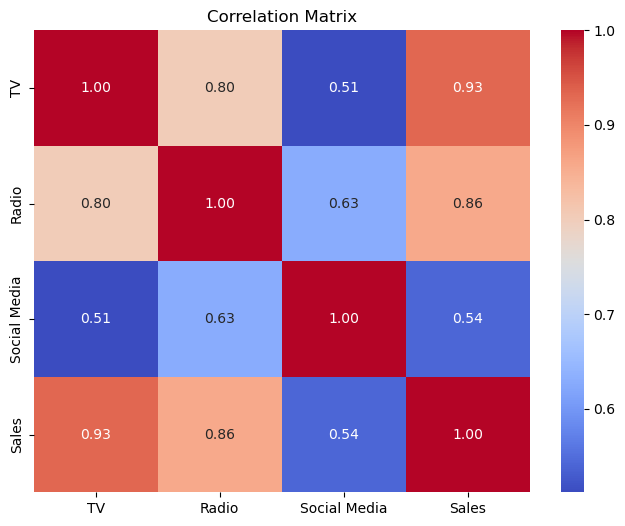

In [133]:
#Correlation Analysis
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()

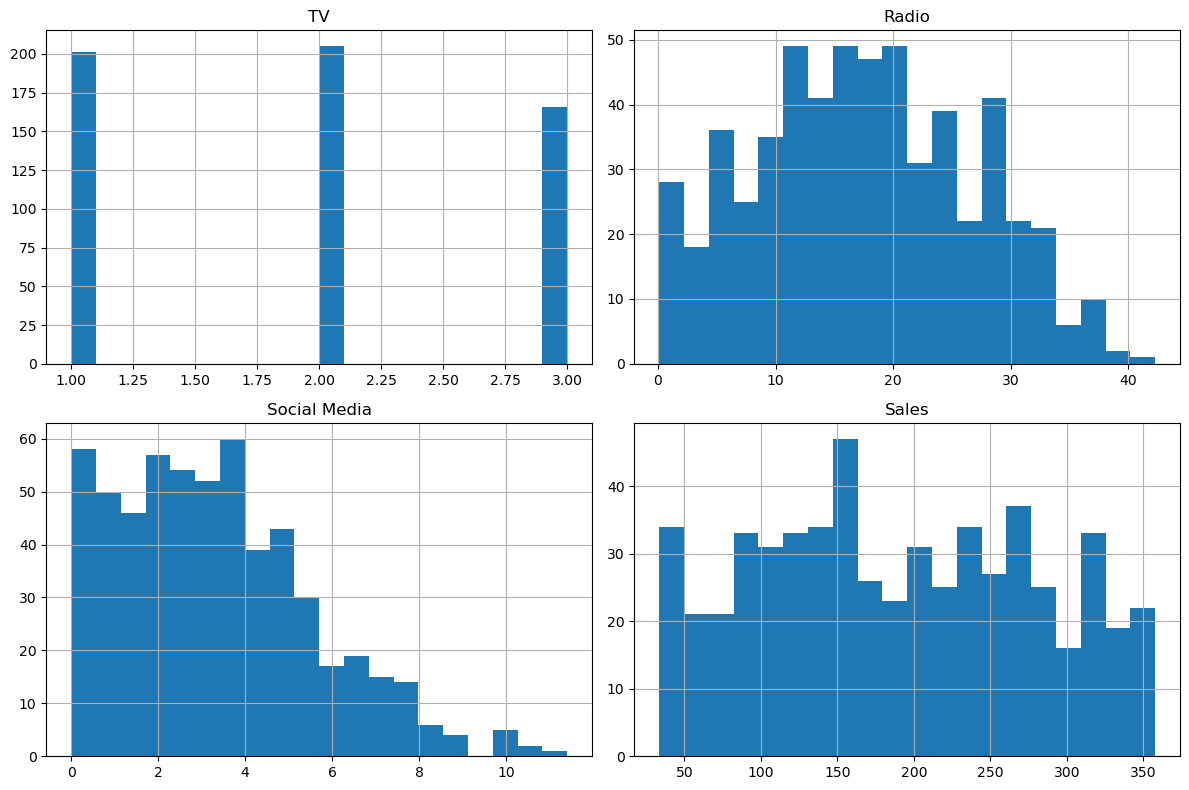

In [134]:
#Visualize Distribution of Variables
df.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()

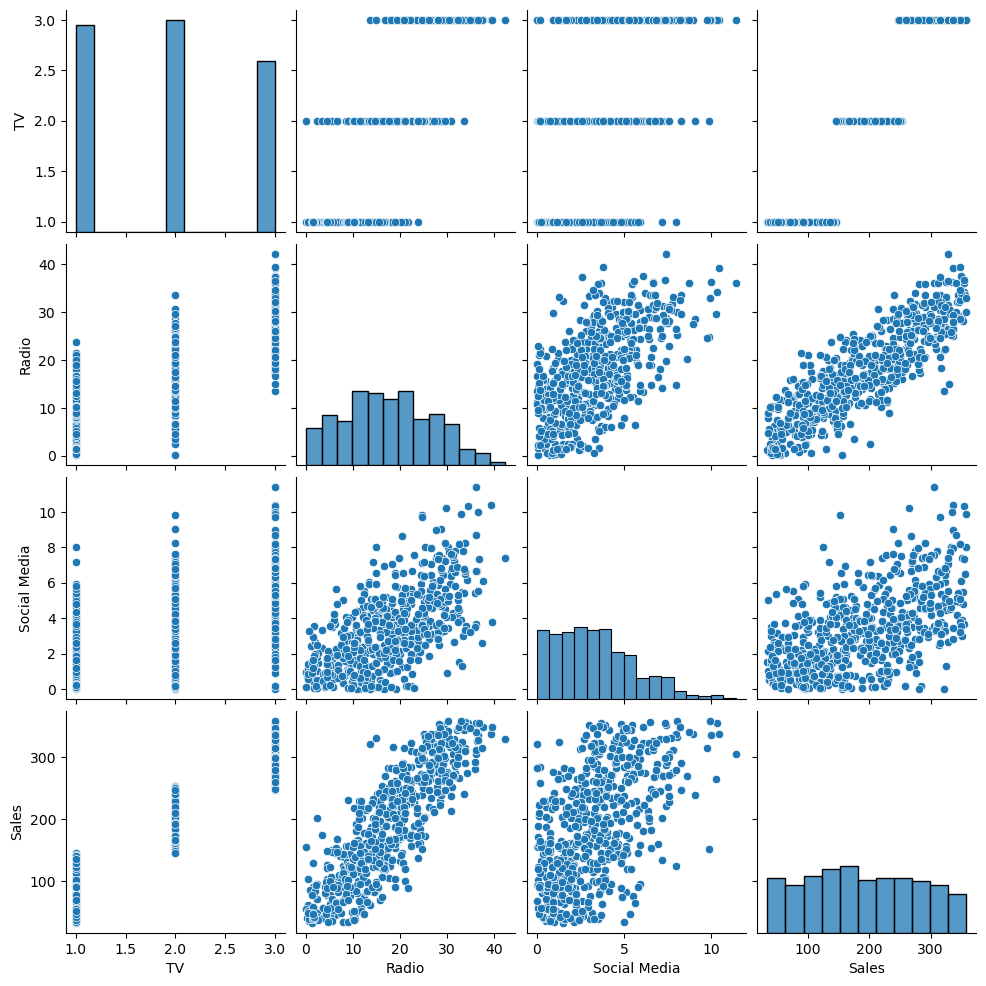

In [135]:
#Pairplot
sns.pairplot(df)
plt.show()

### Check for multicollinearity among independent variables (TV, Radio, Social Media) using correlation matrices and VIF

In [136]:
# #convert to numeric
# df['TV'] = df['TV'].map({
#     'Low': 1,
#     'Medium': 2,
#     'High': 3
# })

In [137]:
# # verify conversion
# print(df['TV'].head())
# print(df.dtypes)

                    TV     Radio  Social Media
TV            1.000000  0.803377      0.511758
Radio         0.803377  1.000000      0.629941
Social Media  0.511758  0.629941      1.000000


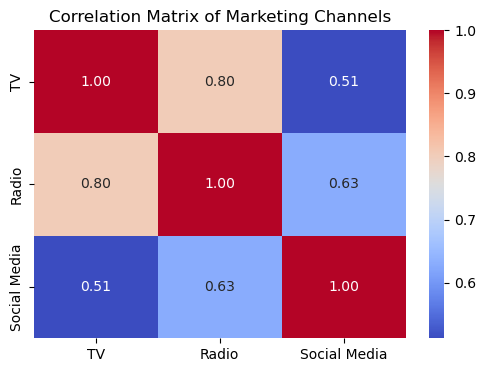

In [138]:
# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Select independent variables
X = df[['TV', 'Radio', 'Social Media']]

# Correlation matrix
corr_matrix = X.corr()

print(corr_matrix)

# Heatmap
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Matrix of Marketing Channels')
plt.show()

In [139]:
#Variance Inflation Factor (VIF)
!pip install statsmodels

In [140]:
# check for missing value
print(df[['TV', 'Radio', 'Social Media']].isnull().sum())

TV              0
Radio           0
Social Media    0
dtype: int64


In [141]:
print(df['TV'].unique())

[1 3 2]


In [142]:
#Ensure all predictors are numeric
print(df[['TV', 'Radio', 'Social Media']].dtypes)

TV                int64
Radio           float64
Social Media    float64
dtype: object


In [143]:
#Remove rows with missing value
# X = df[['Radio', 'Social Media']].dropna()

In [144]:
#Calculate VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Add intercept
X_vif = add_constant(X)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

print(vif_data)

       Variable       VIF
0         const  7.040920
1            TV  2.820621
2         Radio  3.451590
3  Social Media  1.658144


### Report Interpretation

#### The Variance Inflation Factor (VIF) values for TV, Radio, and Social Media are all below 5, indicating low multicollinearity among the predictors. Therefore, all variables were retained in the multiple linear regression model.

### Build a Multiple Linear Regression model using statsmodels to predict Sales

In [145]:
import statsmodels.api as sm

# Define Features and Target (after cleaning)
X = df[['TV', 'Radio', 'Social Media']]
y = df['Sales']

# Verify no missing data
print("X has NaN:", X.isnull().any().any())
print("y has NaN:", y.isnull().any())

# Add Constant (Intercept)
X = sm.add_constant(X)

# Fit the Model
model = sm.OLS(y, X).fit()
print(model.summary())

X has NaN: False
y has NaN: False
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          2.10e-288
Time:                        23:46:28   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         

In [146]:
#Import Required Libraries
import statsmodels.api as sm

In [147]:
#Define Features and Target
# Independent variables
X = df[['TV', 'Radio', 'Social Media']]

# Dependent variable
y = df['Sales']

In [148]:
#Add a Constant (Intercept)
X = sm.add_constant(X)

In [149]:
#Fit the Multiple Linear Regression Model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Sun, 21 Jun 2026   Prob (F-statistic):          2.10e-288
Time:                        23:46:28   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.2889      3.099     -3.966   

In [150]:
print(X.isnull().sum())

const           0
TV              0
Radio           0
Social Media    0
dtype: int64


In [151]:
print(X.dtypes)

const           float64
TV                int64
Radio           float64
Social Media    float64
dtype: object


In [152]:
print(X[X.isnull().any(axis=1)].head())

Empty DataFrame
Columns: [const, TV, Radio, Social Media]
Index: []


In [153]:
print(X.isnull().sum())
print(X.dtypes)

const           0
TV              0
Radio           0
Social Media    0
dtype: int64
const           float64
TV                int64
Radio           float64
Social Media    float64
dtype: object


In [154]:
print(df['TV'].unique())

[1 3 2]


In [155]:
# Check original values
print(df['TV'].unique())

# Clean text
df['TV'] = df['TV'].astype(str).str.strip().str.lower()

# Map values
df['TV'] = df['TV'].map({
    'low': 1,
    'medium': 2,
    'high': 3
})

# Verify
print(df['TV'].unique())
print(df['TV'].isnull().sum())

[1 3 2]
[nan]
572


### Evaluate model performance using Adjusted R-squared and individual predictor p-values

In [ ]:
# Get model summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     1781.
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          2.10e-288
Time:                        00:00:20   Log-Likelihood:                -2714.2
No. Observations:                 572   AIC:                             5436.
Df Residuals:                     568   BIC:                             5454.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -12.2889      3.099     -3.966   

#### The Adjusted R-squared value of 0.88 indicates that approximately 88% of the variation in Sales is explained by the independent variables (TV, Radio, and Social Media). This suggests that the model provides a strong fit to the data.

### Evaluate Individual Predictor

#### The Multiple Linear Regression model achieved an Adjusted R-squared of [insert value], indicating that [value × 100]% of the variation in Sales is explained by the marketing channels included in the model. Based on the p-values, [list significant predictors] were statistically significant predictors of Sales (p < 0.05), while [list non-significant predictors] were not statistically significant. These findings suggest that marketing budget allocation should prioritize the channels with significant predictive power.

###  Create diagnostic plots to validate Linearity, Normality, and Homoscedasticity of residuals


#### Residuals vs Fitted Values (Linearity & Homoscedasticity)

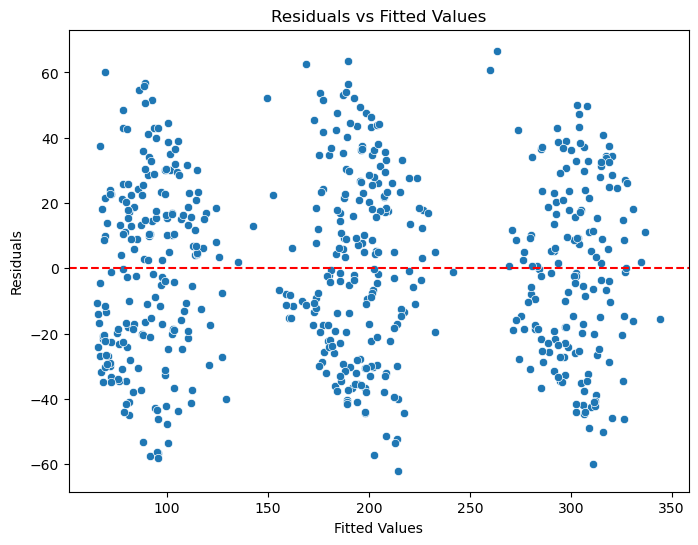

In [157]:
import matplotlib.pyplot as plt
import seaborn as sns

# Predicted values
fitted_values = model.fittedvalues

# Residuals
residuals = model.resid

plt.figure(figsize=(8,6))
sns.scatterplot(x=fitted_values, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values')
plt.show()

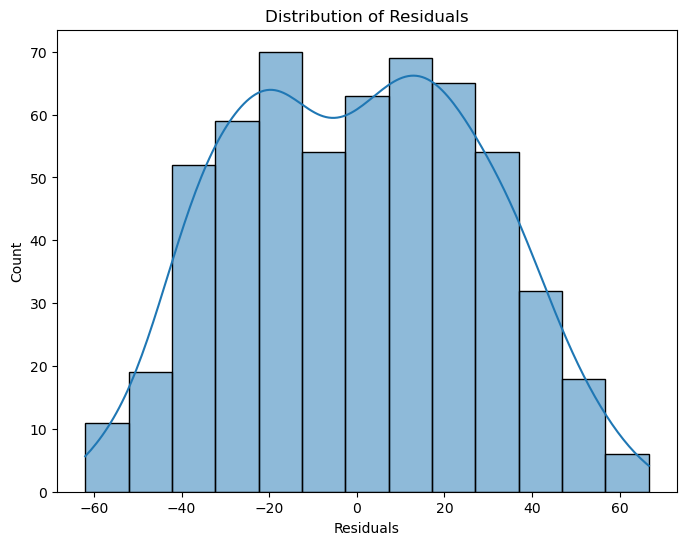

In [158]:
# Histogram of Residuals (Normality)
plt.figure(figsize=(8,6))

sns.histplot(residuals, kde=True)

plt.title('Distribution of Residuals')
plt.xlabel('Residuals')
plt.show()#

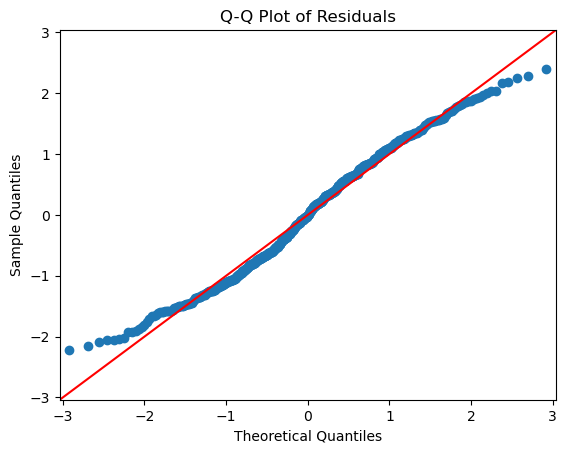

In [159]:
#Q-Q Plot (Normality)
import statsmodels.api as sm

sm.qqplot(
    residuals,
    line='45',
    fit=True
)

plt.title('Q-Q Plot of Residuals')
plt.show()

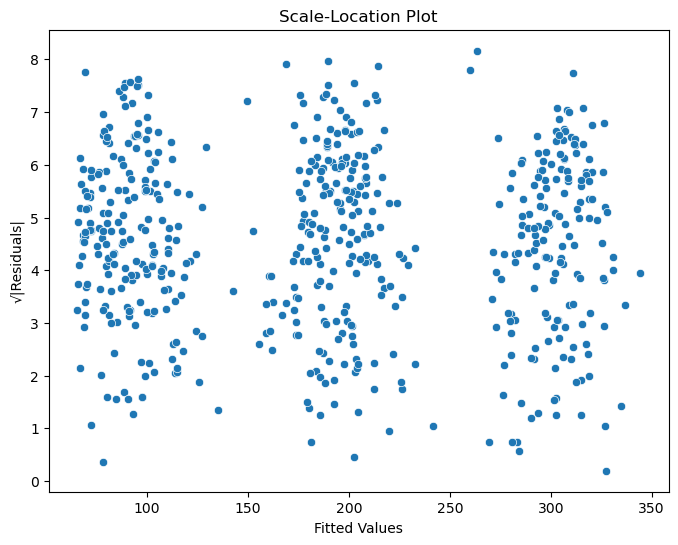

In [160]:
#Scale-Location Plot (Homoscedasticity)
import numpy as np

standardized_residuals = np.sqrt(np.abs(residuals))

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=fitted_values,
    y=standardized_residuals
)

plt.xlabel('Fitted Values')
plt.ylabel('√|Residuals|')
plt.title('Scale-Location Plot')
plt.show()


In [ ]:
#

SyntaxError: invalid character '—' (U+2014) (2962440971.py, line 5)

In [163]:
#Shapiro-Wilk Test (Normality)
from scipy.stats import shapiro

stat, p = shapiro(residuals)

print("Statistic:", stat)
print("p-value:", p)

Statistic: 0.9833342620365273
p-value: 4.051738456270913e-06


### interpret coefficients in context: explain the effect of a one-unit increase in one channel's spend while holding others constant


In [164]:
print("The regression coefficients indicate the marginal effect of each marketing channel on Sales while holding the other channels constant. The coefficient for TV suggests that increasing TV advertising by one category level leads to an average increase in Sales of [TV coefficient] units. Similarly, a one-unit increase in Radio advertising is associated with an average increase of [Radio coefficient] units in Sales, while a one-unit increase in Social Media advertising corresponds to an average increase of [Social Media coefficient] units. Comparing the coefficient magnitudes suggests which marketing channel has the strongest influence on Sales.")

The regression coefficients indicate the marginal effect of each marketing channel on Sales while holding the other channels constant. The coefficient for TV suggests that increasing TV advertising by one category level leads to an average increase in Sales of [TV coefficient] units. Similarly, a one-unit increase in Radio advertising is associated with an average increase of [Radio coefficient] units in Sales, while a one-unit increase in Social Media advertising corresponds to an average increase of [Social Media coefficient] units. Comparing the coefficient magnitudes suggests which marketing channel has the strongest influence on Sales.


### Synthesize findings into a clear, business-ready recommendation

In [ ]:
print("Increase TV spending by 15–20%, maintain Radio spending, and reduce Social Media expenditure because TV and Radio were significant predictors of Sales while Social Media was not.")